# Neural Network for CIFAR-10 classification


In this hometask you'll implement and train neural networks for classification of images from the CIFAR-10 dataset.


CIFAR-10 is a dataset of small **color** images from 10 object classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck. Each image has size **32×32×3**. This makes the task harder than MNIST, because now the images are colored and the objects are much more visually diverse.


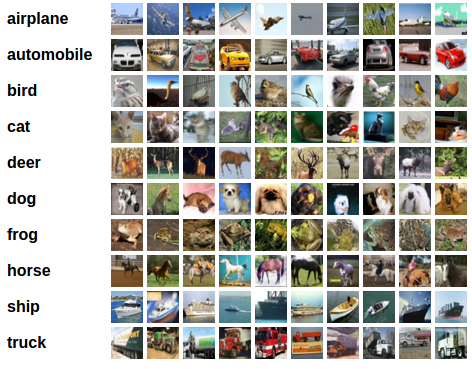

We will also visualize a few CIFAR-10 images after loading the dataset.


## Loading data


The cell below downloads CIFAR-10 using `torchvision`.


In [71]:
import torchvision
from torchvision import transforms

train_dataset_raw = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True
)
test_dataset_raw = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True
)


/Users/dgwalters/Desktop/CIFAR-10/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


After this, you'll have the CIFAR-10 training and testing splits downloaded into the `./data` directory.


Let's import NumPy, Pandas and look at our data:


In [72]:
import numpy as np
import pandas as pd

In [73]:
class_names = train_dataset_raw.classes

train_images = train_dataset_raw.data
test_images = test_dataset_raw.data
train_labels = np.array(train_dataset_raw.targets)
test_labels = np.array(test_dataset_raw.targets)

# flatten images so that each object is represented as a vector
train_flat = train_images.reshape(len(train_images), -1)
test_flat = test_images.reshape(len(test_images), -1)

train_data = pd.DataFrame(train_flat)
train_data['label'] = train_labels

test_data = pd.DataFrame(test_flat)
test_data['label'] = test_labels

train_data.head()


,0,1,2,3,4,5,6,7,8,9,...,3063,3064,3065,3066,3067,3068,3069,3070,3071,label
0,59,62,63,43,46,45,50,48,43,68,...,216,184,140,151,118,84,123,92,72,6
1,154,177,187,126,137,136,105,104,95,102,...,143,133,139,143,134,142,143,133,144,9
2,255,255,255,253,253,253,253,253,253,253,...,78,85,83,79,85,83,80,86,84,9
3,28,25,10,37,34,19,38,35,20,42,...,54,47,28,63,56,37,72,65,46,4
4,170,180,198,168,178,196,177,185,203,183,...,75,79,82,71,75,78,73,77,80,1


In this table, each image is represented as a vector of size **32×32×3 = 3072**, where each feature corresponds to one pixel channel (Red, Green or Blue) value. Pixel values are in the range **[0, 255]**.

Column `label` is the target variable representing the image class. The class mapping is:

```python
{idx: name for idx, name in enumerate(class_names)}
```


Let's visualize the first image:


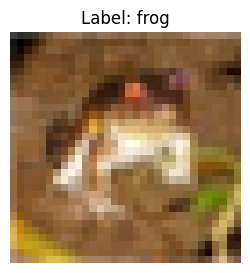

In [74]:
import matplotlib.pyplot as plt

# you can change the index and visualize different images
idx = 0
img = train_images[idx]
plt.figure(figsize=(3, 3))
plt.imshow(img)
plt.title(f'Label: {class_names[train_labels[idx]]}')
plt.axis('off');

Let's also load test data:


In [75]:
# test_data has already been created above
test_data.head()

,0,1,2,3,4,5,6,7,8,9,...,3063,3064,3065,3066,3067,3068,3069,3070,3071,label
0,158,112,49,159,111,47,165,116,51,166,...,24,77,124,34,84,129,21,67,110,3
1,235,235,235,231,231,231,232,232,232,232,...,168,183,178,180,195,191,186,200,199,8
2,158,190,222,158,187,218,139,166,194,132,...,5,6,8,4,5,3,7,8,7,8
3,155,156,149,167,176,187,176,179,193,190,...,60,63,50,64,65,52,73,68,50,0
4,65,68,50,70,81,64,48,64,46,30,...,143,179,136,154,185,146,128,156,117,6


## Task 1. Binary classification with NNs


In this first task you'll define and train a neural network for **binary classification** of CIFAR-10 images.

As we have 10 classes in the full dataset, we'll first extract parts of the data containing only two classes.

We will solve two tasks: classification of classes that usually look quite different (**frog** vs **ship**) and classification of classes that are much easier to confuse (**cat** vs **dog**). It is interesting to see how these tasks differ in difficulty and whether different neural network architectures or hyperparameters are optimal for them.


So let's extract data for frog/ship classification and for cat/dog classification:


In [76]:
# frog / ship classification
labels_to_train = [class_names.index('frog'), class_names.index('ship')]
train_data_frog_ship = train_data[train_data['label'].isin(labels_to_train)].copy()
test_data_frog_ship = test_data[test_data['label'].isin(labels_to_train)].copy()

# convert labels to 0/1 for binary classification
train_data_frog_ship['label'] = (train_data_frog_ship['label'] == class_names.index('ship')).astype(int)
test_data_frog_ship['label'] = (test_data_frog_ship['label'] == class_names.index('ship')).astype(int)

# divide data into features and target variable
X_train_frog_ship = train_data_frog_ship.drop(columns=['label'])
y_train_frog_ship = train_data_frog_ship['label']
X_test_frog_ship = test_data_frog_ship.drop(columns=['label'])
y_test_frog_ship = test_data_frog_ship['label']


In [77]:
# cat / dog classification
labels_to_train = [class_names.index('cat'), class_names.index('dog')]
train_data_cat_dog = train_data[train_data['label'].isin(labels_to_train)].copy()
test_data_cat_dog = test_data[test_data['label'].isin(labels_to_train)].copy()

# convert labels to 0/1 for binary classification
train_data_cat_dog['label'] = (train_data_cat_dog['label'] == class_names.index('dog')).astype(int)
test_data_cat_dog['label'] = (test_data_cat_dog['label'] == class_names.index('dog')).astype(int)

# divide data into features and target variable
X_train_cat_dog = train_data_cat_dog.drop(columns=['label'])
y_train_cat_dog = train_data_cat_dog['label']
X_test_cat_dog = test_data_cat_dog.drop(columns=['label'])
y_test_cat_dog = test_data_cat_dog['label']


### Task 1.1. Write a neural network for binary classification (4 points)


For now, write any architecture that would consume a flattened CIFAR-10 image and output the probability of class 1. Think about the following:
- How many input and output neurons should your network have?
- What activation function should the last layer have?


In [78]:
import torch.nn as nn

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()

        # define layers and activation function that your model will have
        # YOUR CODE HERE
        self.linear1 = nn.Linear(3072, 1024)
        self.relu = nn.ReLU()
        self.linear2 = nn.Linear(1024, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        # define a flow of input through your layers
        # YOUR CODE HERE
        x = self.linear1(x)
        x = self.relu(x)
        x = self.linear2(x)
        x = self.sigmoid(x)
        return x

And create a network:


In [79]:
net = Net()

### Task 1.2. Define a train function. (4 points)


You can borrow the code from our practical session.

It might also be beneficial to see how training loss evolves during training, this will help you do experiments later. You can either save average of losses on batches per epoch into array and return it as output of the `train` function, so you can then visualize it using [matplotlib.plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html). Or you can add plotting average of losses on batches per epoch inside the `train` function. In this case you might also need using a function to clear output of the cell, so you can draw new plot after each epoch. You can find how to do it [here](https://stackoverflow.com/questions/24816237/ipython-notebook-clear-cell-output-in-code)


In [80]:
import tqdm
from tqdm.auto import tqdm
import torch
from torch.utils.data import DataLoader # Corrected import



def train(model, dataloader, criterion, optimizer, num_epoch):
    model.train()

    loss_history = []
    
    for epoch in tqdm(range(num_epoch)):
      epoch_loss = 0.0
      for x, y in dataloader:
        optimizer.zero_grad()
        y_pred = model(x)
        loss = criterion(y_pred, y)
        
        epoch_loss += loss.item()
        loss.backward()
        optimizer.step()
        
      loss_history.append(epoch_loss / len(dataloader))
    
    # returns trained model
    return model, loss_history


And let's define loss function, optimizer, dataloader and train our network. For now, use `train_data_frog_ship` to pass to the dataloader.


In [81]:
import torch
from torch.utils.data import Dataset, DataLoader

# Define a simple Dataset for Task 1 (not required but less of a faff than converting to tensors etc manually & it gets used later anyway)
class BinaryClassificationDataset(Dataset):
    def __init__(self, dataframe):
        # Convert features to numpy array of float type for tensor conversion
        self.data = dataframe.drop(columns=['label']).values.astype(float) / 255.0
        # Convert labels to numpy array of float type, unsqueeze for BCELoss
        self.labels = dataframe['label'].values.astype(float)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        features = torch.tensor(self.data[idx], dtype=torch.float32)
        label = torch.tensor(self.labels[idx], dtype=torch.float32).unsqueeze(0) # Add a dimension for BCELoss
        return features, label

# training dataset
train_dataset = BinaryClassificationDataset(train_data_frog_ship)


# loss function
criterion = nn.BCELoss() # define a loss function (binary cross-entropy)

# optimizer
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3) # define an optimizer and pass params of neural network to it

# dataloader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True) # define a train loader



In [82]:
# run training
net, loss_history = train(net, train_loader, criterion, optimizer, 60)

100%|██████████| 60/60 [01:49<00:00,  1.83s/it]


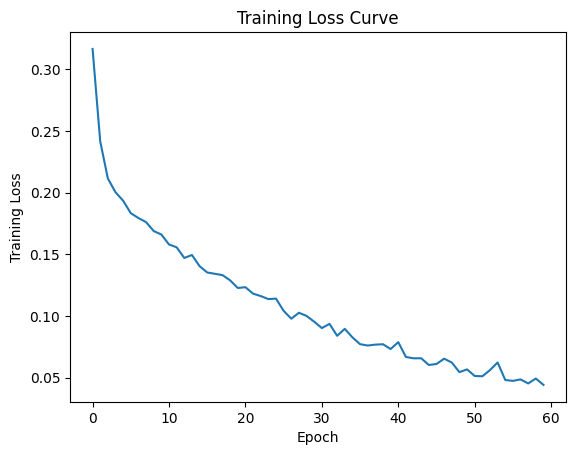

In [83]:
# check loss history graphically
def plot_simple_loss_history(loss_history):
    plt.plot(loss_history)
    plt.xlabel('Epoch')
    plt.ylabel('Training Loss')
    plt.title('Training Loss Curve')
    plt.show()
    
plot_simple_loss_history(loss_history)

### Task 1.3. Write a code for model evaluation (4 points)


After we train our neural network, we'll need to evaluate it on test data and compute accuracy metric. Let's now define the function for it. Your task is to fill the gaps in the code below


In [84]:
import numpy as np
from sklearn.metrics import accuracy_score

def evaluate(model, loader, criterion):
    '''
    args:
        model - our neural network model
        loader — structure which yields batches of test data
        criterion - loss function from `torch.nn` module
    '''
    model.eval() # Set model to evaluation mode

    # arrays for storing loss values, network predictions and true values
    losses = []
    y_pred_list = []
    y_true_list = []

    for X_batch, y_batch in loader:

        # this disables gradient computations to save time and memory
        # we don't need gradients on test data
        with torch.no_grad():
            # getting our model's predictions on current batch
            y_pred = model(X_batch) # Corrected to use 'model' argument

            # calculate loss function
            loss = criterion(y_pred, y_batch) # y_pred first for BCELoss
            losses.append(loss.item())

        # convert outputs of your network into class number
        y_pred_class = (y_pred > 0.5).int() # Convert boolean to int (0 or 1)

        # save for accuracy calculation
        y_pred_list.extend(y_pred_class.cpu().numpy().flatten()) # Flatten and move to numpy
        y_true_list.extend(y_batch.cpu().numpy().flatten()) # Flatten and move to numpy

    # calculate accuracy score based on y_pred_list and y_true_list
    accuracy = accuracy_score(y_true_list, y_pred_list)

    return np.mean(losses), accuracy


And let's evaluate our trained network on test data. Use `test_data_frog_ship` for testing.


In [85]:
test_dataset = BinaryClassificationDataset(test_data_frog_ship)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False) # Define a test loader

mean_loss, accuracy = evaluate(net, test_loader, criterion)
print(f"Mean Test Loss: {mean_loss:.4f}, Test Accuracy: {accuracy:.4f}")


Mean Test Loss: 0.2288, Test Accuracy: 0.9400


### Task 1.4. Train the neural network to classify frog/ship images (9 points)


Now you have a network that can be trained and evaluated on binary classification data. Your task is to improve it so that your neural network can achieve **>0.94 accuracy** on the test part.

You are free to build any neural network architecture you want and use any hyperparameters for training. Here are some tips:
- Start with 1-3 hidden layers having, for example, 64-256 neurons each
- Think about how many neurons your input and output layers should have
- What activation function do you need to use in the last layer?
- Play with number of layers, number of neurons, and different activation functions
- Try different training **hyperparameters**: learning rate, number of epochs, optimizer type, batch size

After you've done experimenting, describe your findings. Try to answer the following questions:
- How large should the neural network be to solve the task successfully? There are two dimensions to neural network size: **depth** (number of layers) and **width** (number of neurons in a layer).
- How does the behaviour of the model change when you change different hyperparameters?
- What interesting behaviour have you observed? What was beneficial and what did not influence the model?
- How does the number of epochs needed to achieve the same loss value change when you change the activation function? Fix the network architecture and all training hyperparameters and train the neural network with three different activation functions in hidden layers (Sigmoid, Tanh, ReLU). Plot how training loss evolves during training in these three cases.


In [86]:
# Imports (in case we need to do again...covers all imports needed)
import torch.nn as nn
import tqdm
from tqdm.auto import tqdm
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.metrics import accuracy_score


## Logistic Regression as a base case...

In [ ]:
# Logistic Regression Model (as a baseline)
class NetLogistic(nn.Module):
    def __init__(self):
        super(NetLogistic, self).__init__()

        # define layers and activation function that your model will have
        # YOUR CODE HERE
        self.linear1 = nn.Linear(3072, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        # define a flow of input through your layers
        # YOUR CODE HERE
        x = self.linear1(x)
        x = self.sigmoid(x)
        return x

net_logistic = NetLogistic() #define new model
optimizer = torch.optim.Adam(net_logistic.parameters(), lr=1e-4) #define new optimizer
criterion = nn.BCELoss() #define new loss function

train_dataset = BinaryClassificationDataset(train_data_frog_ship)            
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# run training
net_logistic, loss_history_logistic = train(net_logistic, train_loader, criterion, optimizer, 100)

# test_dataset = BinaryClassificationDataset(test_data_frog_ship)
# test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False) # Define a test loader

mean_loss, accuracy = evaluate(net_logistic, test_loader, criterion)
print(f"Test Loss: {mean_loss:.4f}, Test Accuracy: {accuracy:.4f}")

# Network summary                                     
print(f"\nNetwork Architecture: {net_logistic}")                 
print(f"\nTotal parameters: {sum(p.numel() for p in 
net_logistic.parameters()):,}")                                  
print(f"Trainable parameters: {sum(p.numel() for p in 
net_logistic.parameters() if p.requires_grad):,}")               
                
# Per-layer breakdown                          
print("\nLayer details:")
for name, param in net_logistic.named_parameters():
    print(f"  {name}: {list(param.shape)} ({param.numel():,} params)")

100%|██████████| 100/100 [00:34<00:00,  2.86it/s]

Test Loss: 0.1982, Test Accuracy: 0.9300

Network Architecture: NetLogistic(
  (linear1): Linear(in_features=3072, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

Total parameters: 3,073
Trainable parameters: 3,073

Layer details:
  linear1.weight: [1, 3072] (3,072 params)
  linear1.bias: [1] (1 params)


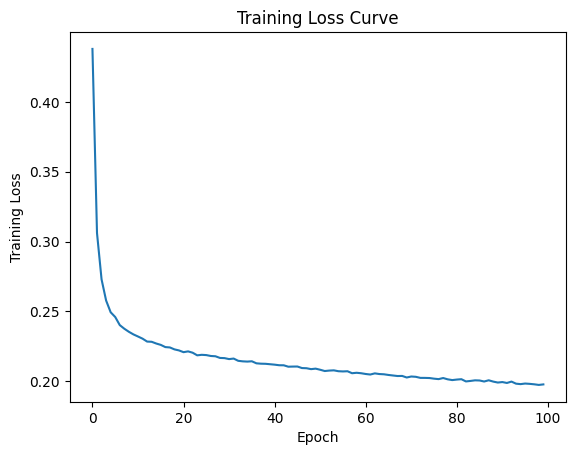

In [40]:
# let's have a look at the loss history...
plot_simple_loss_history(loss_history_logistic)

100%|██████████| 100/100 [00:35<00:00,  2.84it/s]


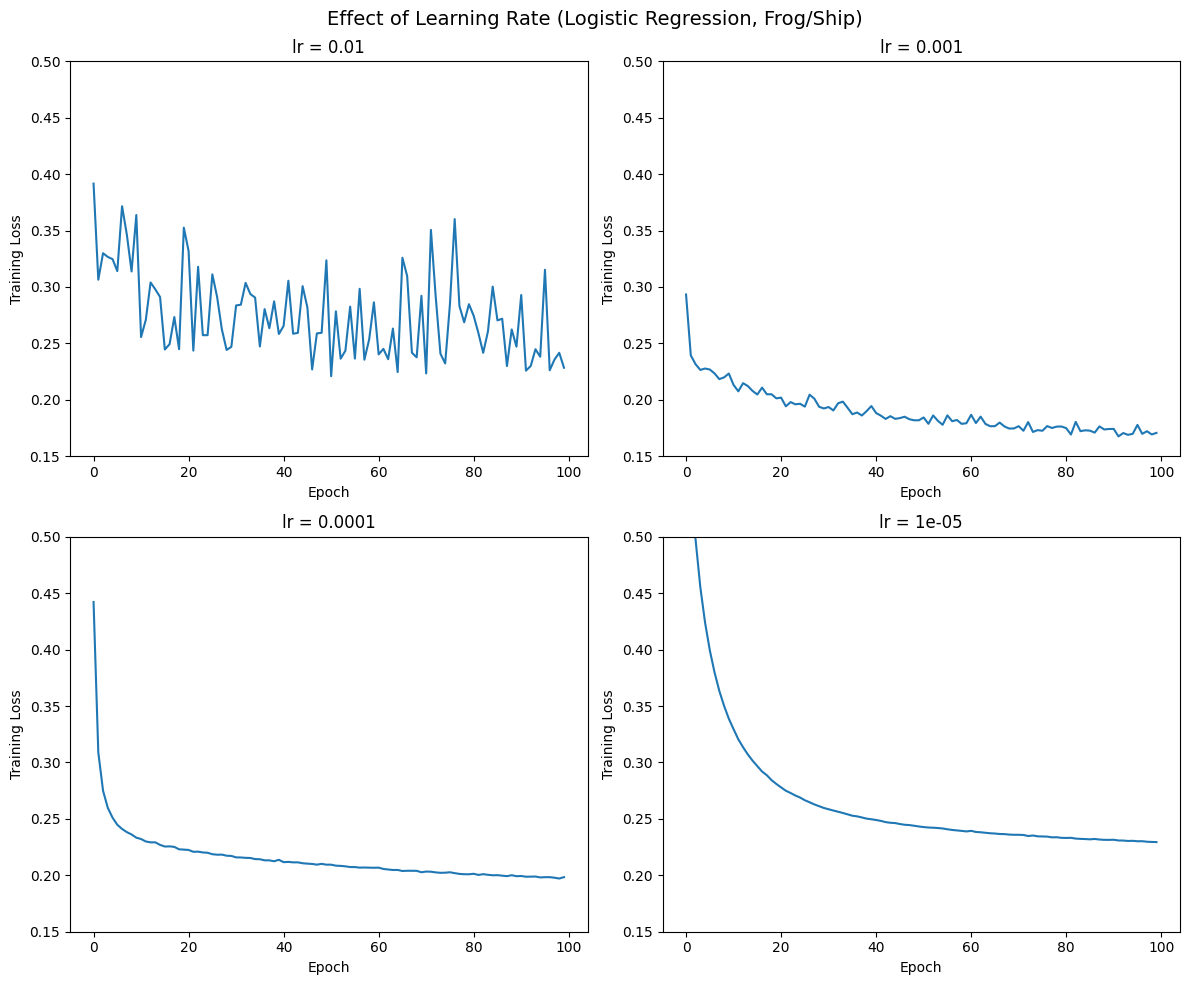

lr         Final Train Loss     Test Loss       Test Accuracy  
------------------------------------------------------------
0.01       0.2284               0.3144          0.9120         
0.001      0.1707               0.1972          0.9255         
0.0001     0.1984               0.1998          0.9265         
1e-05      0.2294               0.2277          0.9105         


In [41]:
# Sweep learning rates on logistic regression model                
lr_values = [1e-2, 1e-3, 1e-4, 1e-5]                               
lr_results = []                                                    
                                                                    
for lr in lr_values:
    model = NetLogistic()                                          
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    model, loss_history = train(model, train_loader, criterion, optimizer, 100) 
    test_loss, test_accuracy = evaluate(model, test_loader, criterion)                                     
    lr_results.append({
        'lr': lr,
        'loss_history': loss_history,
        'test_loss': test_loss,
        'test_accuracy': test_accuracy,
        'final_train_loss': loss_history[-1],
    })

# Plot panel of 4 charts
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Effect of Learning Rate (Logistic Regression, Frog/Ship)', fontsize=14)

for ax, res in zip(axes.flat, lr_results):
    ax.plot(res['loss_history'])
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Training Loss')
    ax.set_title(f"lr = {res['lr']}")
    ax.set_ylim(0.15, 0.50)  # fixed y-axis for fair comparison

plt.tight_layout()
plt.show()

# Summary table
print(f"{'lr':<10} {'Final Train Loss':<20} {'Test Loss':<15} {'Test Accuracy':<15}")
print("-" * 60)
for res in lr_results:
    print(f"{res['lr']:<10} {res['final_train_loss']:<20.4f} {res['test_loss']:<15.4f} {res['test_accuracy']:<15.4f}")

### Now I try to process multiple models (different sizes) and chart the outputs for comparison:

In [42]:
# build pipeline to process multiple params
def pipeline(config, train_df, test_df):                           
      # 1. Extract config                        
      layer_sizes = config['layer_sizes']                            
      act_name = config['activation']
                                                 
      # Map activation name to nn module         
      act_map = {'relu': nn.ReLU(), 'tanh': nn.Tanh(), 'sigmoid': nn.Sigmoid()}
      activation_fn = act_map[act_name]

      # 2. Build model
      layers = []
      for i in range(len(layer_sizes) - 1):
          layers.append(nn.Linear(layer_sizes[i], layer_sizes[i + 1]))
          if i < len(layer_sizes) - 2:
              layers.append(activation_fn)
          else:
              layers.append(nn.Sigmoid())
      model = nn.Sequential(*layers)

      # 3. Set up training
      criterion = nn.BCELoss()
      opt_map = {'adam': torch.optim.Adam, 'sgd': torch.optim.SGD}
      optimizer = opt_map[config['optimizer']](model.parameters(), lr=config['lr'])

      train_dataset = BinaryClassificationDataset(train_df)
      test_dataset = BinaryClassificationDataset(test_df)
      train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)
      test_loader = DataLoader(test_dataset, batch_size=config['batch_size'], shuffle=False)

      # 4. Train and track loss history
      model.train()
      loss_history = []
      for epoch in range(config['epochs']):
          epoch_loss = 0.0
          for x, y in train_loader:
              optimizer.zero_grad()
              y_pred = model(x)
              loss = criterion(y_pred, y)
              loss.backward()
              optimizer.step()
              epoch_loss += loss.item()
          loss_history.append(epoch_loss / len(train_loader))

      # 5. Evaluate
      test_loss, test_accuracy = evaluate(model, test_loader,
  criterion)

      # 6. Return results
      return {
          'config': config,
          'train_loss_final': loss_history[-1],
          'test_loss': test_loss,
          'test_accuracy': test_accuracy,
          'loss_history': loss_history,
      }

### First up I try a bunch of architectures to see what works etc. All models run with tanh and relu (sigmoid at end but try both tanh and ReLu in the middle for some different networks)

In [89]:
results = []
for activation in ['relu', 'tanh']:
    for layer_sizes in [[3072, 1], [3072, 1024, 512, 1], [3072, 512, 256, 64, 1], [3072, 256, 128, 1]]:
        config = {'layer_sizes': layer_sizes,
                   'activation': activation,
                    'lr': 1e-4, 'epochs': 60, 
                    'batch_size': 32,
                    'optimizer': 'adam'}
        result = pipeline(config, train_data_frog_ship, test_data_frog_ship)
        results.append(result)

results_df = pd.DataFrame(results)

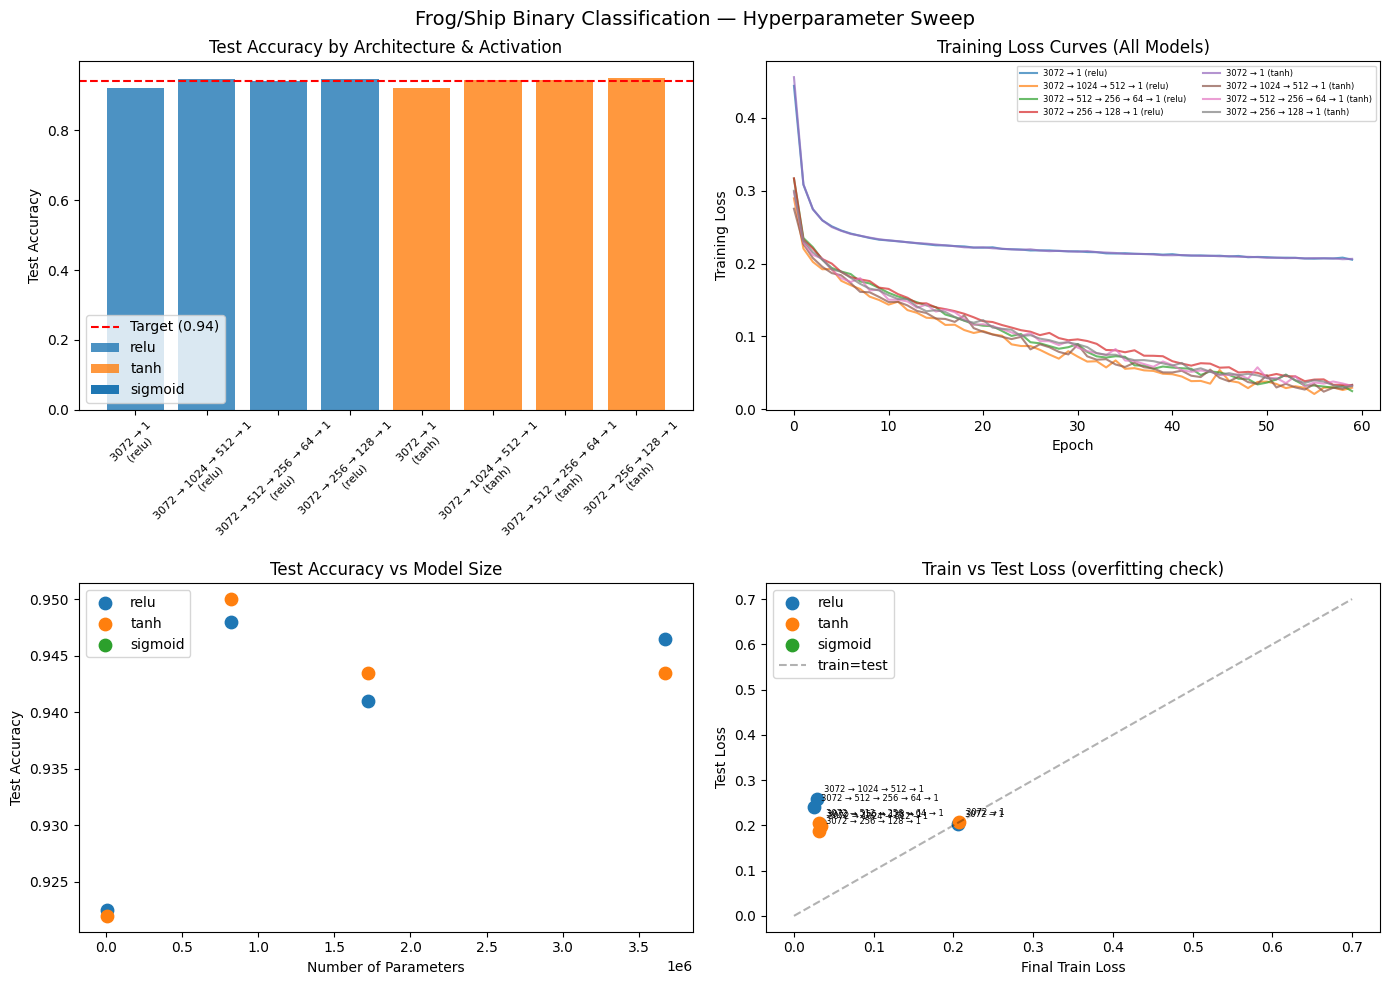

In [90]:
import matplotlib.pyplot as plt                                    
   
# Extract helper columns from config dicts                
results_df['activation'] = results_df['config'].apply(lambda c: c['activation'])                                                   
results_df['architecture'] = results_df['config'].apply(lambda c: ' → '.join(map(str, c['layer_sizes']))) 
results_df['num_params'] = results_df['config'].apply(lambda c: sum(c['layer_sizes'][i]*c['layer_sizes'][i+1] + c['layer_sizes'][i+1] for i in range(len(c['layer_sizes'])-1)))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Frog/Ship Binary Classification — Hyperparameter Sweep', fontsize=14)

# 1. Test accuracy by architecture and activation
ax = axes[0, 0]
for act in ['relu', 'tanh', 'sigmoid']:
    subset = results_df[results_df['activation'] == act]
    ax.bar([f"{a}\n({act})" for a in subset['architecture']],
            subset['test_accuracy'], label=act, alpha=0.8)
ax.set_ylabel('Test Accuracy')
ax.set_title('Test Accuracy by Architecture & Activation')
ax.axhline(y=0.94, color='r', linestyle='--', label='Target (0.94)')
ax.legend()
ax.tick_params(axis='x', rotation=45, labelsize=8)

# 2. Loss curves for ALL models
ax = axes[0, 1]
for _, row in results_df.iterrows():
    label = f"{row['architecture']} ({row['activation']})"
    ax.plot(row['loss_history'], label=label, alpha=0.7)
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.set_title('Training Loss Curves (All Models)')
ax.legend(fontsize=6, ncol=2)

# 3. Test accuracy vs number of parameters
ax = axes[1, 0]
for act in ['relu', 'tanh', 'sigmoid']:
    subset = results_df[results_df['activation'] == act]
    ax.scatter(subset['num_params'], subset['test_accuracy'],
label=act, s=80)
ax.set_xlabel('Number of Parameters')
ax.set_ylabel('Test Accuracy')
ax.set_title('Test Accuracy vs Model Size')
ax.legend()

# 4. Train vs test loss with labels
ax = axes[1, 1]
for act in ['relu', 'tanh', 'sigmoid']:
    subset = results_df[results_df['activation'] == act]
    ax.scatter(subset['train_loss_final'], subset['test_loss'],
label=act, s=80)
    for _, row in subset.iterrows():
        label = f"{row['architecture']}"
        ax.annotate(label, (row['train_loss_final'],
row['test_loss']),
                    fontsize=6, textcoords='offset points',
xytext=(5, 5))
ax.plot([0, 0.7], [0, 0.7], 'k--', alpha=0.3, label='train=test')
ax.set_xlabel('Final Train Loss')
ax.set_ylabel('Test Loss')
ax.set_title('Train vs Test Loss (overfitting check)')
ax.legend()

plt.tight_layout()
plt.show()

In [45]:
# Summary table                                           
summary = results_df[['architecture', 'activation', 'num_params', 'train_loss_final', 'test_loss', 'test_accuracy']].copy()          
summary = summary.sort_values('test_accuracy', ascending=False)    
summary.columns = ['Architecture', 'Activation', 'Parameters', 'Train Loss', 'Test Loss', 'Test Accuracy']                        
summary['Parameters'] = summary['Parameters'].apply(lambda x:f"{x:,}")                                      
summary['Train Loss'] = summary['Train Loss'].apply(lambda x:f"{x:.4f}")
summary['Test Loss'] = summary['Test Loss'].apply(lambda x:f"{x:.4f}")
summary['Test Accuracy'] = summary['Test Accuracy'].apply(lambda x:f"{x:.4f}")
print(summary.to_string(index=False))

             Architecture Activation Parameters Train Loss Test Loss Test Accuracy
     3072 → 256 → 128 → 1       relu    819,713     0.0350    0.2075        0.9500
    3072 → 1024 → 512 → 1       tanh  3,672,065     0.0323    0.2173        0.9495
     3072 → 256 → 128 → 1       tanh    819,713     0.0314    0.2112        0.9475
     3072 → 256 → 128 → 1       relu    819,713     0.0329    0.1912        0.9470
    3072 → 1024 → 512 → 1       relu  3,672,065     0.0243    0.2643        0.9465
3072 → 512 → 256 → 64 → 1       tanh  1,721,217     0.0239    0.2233        0.9460
     3072 → 256 → 128 → 1       tanh    819,713     0.0296    0.2069        0.9440
3072 → 512 → 256 → 64 → 1       relu  1,721,217     0.0253    0.2501        0.9435
                 3072 → 1       relu      3,073     0.2063    0.2029        0.9220
                 3072 → 1       tanh      3,073     0.2061    0.2120        0.9160


### Now let's try some more compact models, with narrower layers to avoid the number of parameters blowing up. (these cells need to be run in order)

In [46]:
results = []
for activation in ['relu', 'tanh']:
    for layer_sizes in [[3072, 1], [3072, 64, 1], [3072, 128, 1], [3072, 256, 1], [3072, 512, 1], [3072, 1024, 1]]:
        config = {'layer_sizes': layer_sizes,
                   'activation': activation,
                    'lr': 1e-4, 'epochs': 60, 
                    'batch_size': 32,
                    'optimizer': 'adam'}
        result = pipeline(config, train_data_frog_ship, test_data_frog_ship)
        results.append(result)

results_df = pd.DataFrame(results)                                   


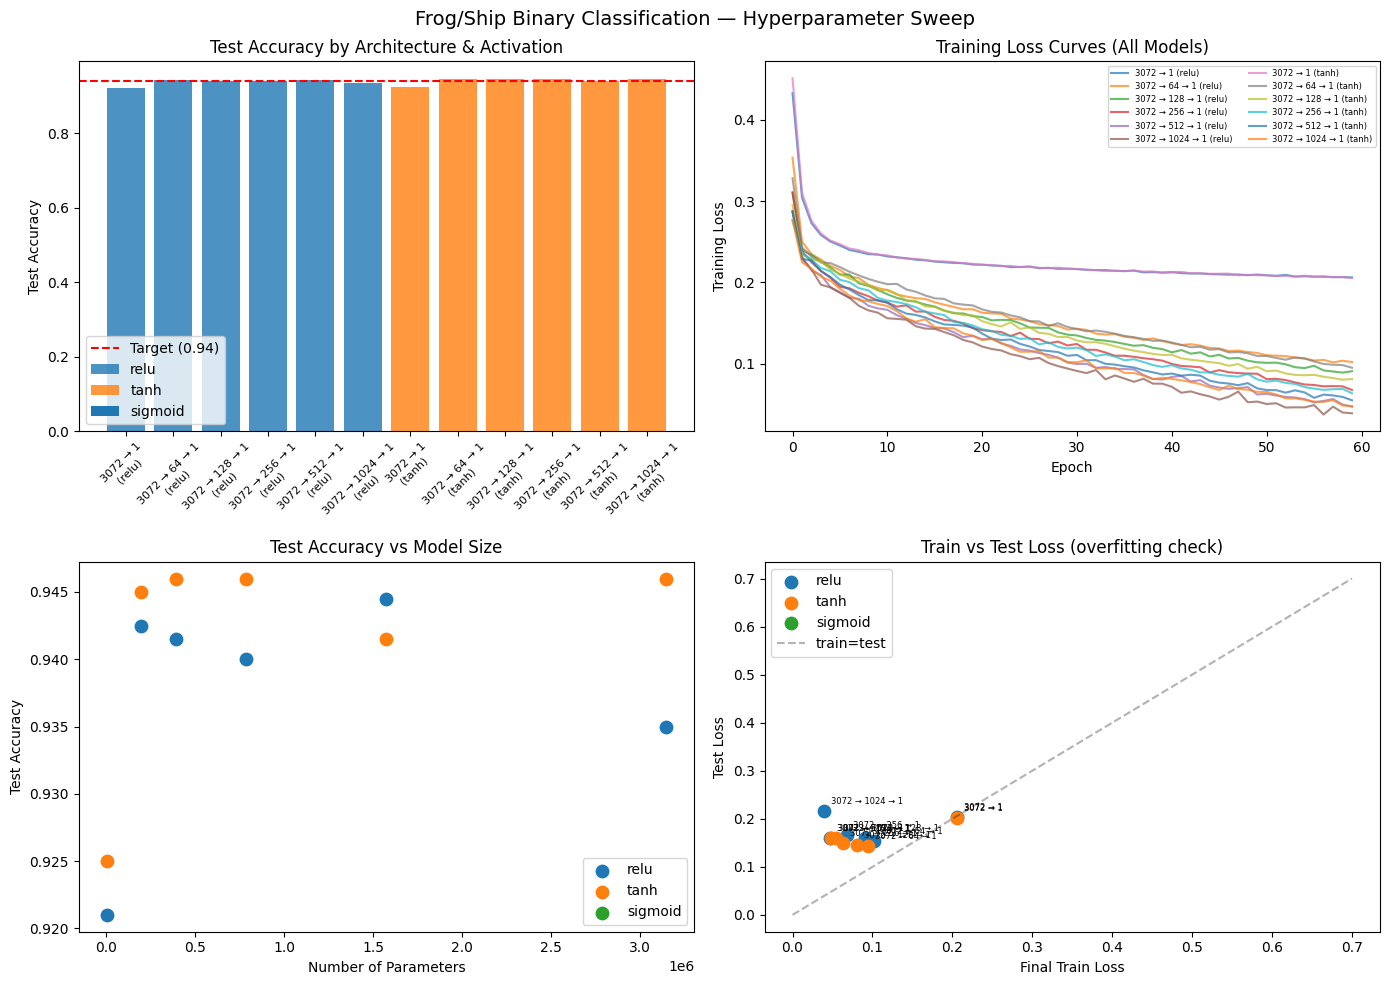

   Architecture Activation Parameters Train Loss Test Loss Test Accuracy
 3072 → 128 → 1       tanh    393,473     0.0810    0.1453        0.9460
 3072 → 256 → 1       tanh    786,945     0.0635    0.1488        0.9460
3072 → 1024 → 1       tanh  3,147,777     0.0478    0.1600        0.9460
  3072 → 64 → 1       tanh    196,737     0.0949    0.1442        0.9450
 3072 → 512 → 1       relu  1,573,889     0.0469    0.1598        0.9445
  3072 → 64 → 1       relu    196,737     0.1019    0.1546        0.9425
 3072 → 128 → 1       relu    393,473     0.0906    0.1609        0.9415
 3072 → 512 → 1       tanh  1,573,889     0.0549    0.1599        0.9415
 3072 → 256 → 1       relu    786,945     0.0675    0.1662        0.9400
3072 → 1024 → 1       relu  3,147,777     0.0389    0.2167        0.9350
       3072 → 1       tanh      3,073     0.2053    0.2020        0.9250
       3072 → 1       relu      3,073     0.2060    0.2047        0.9210


In [47]:
import matplotlib.pyplot as plt 
  
# Extract helper columns from config dicts                
results_df['activation'] = results_df['config'].apply(lambda c: c['activation'])                                                   
results_df['architecture'] = results_df['config'].apply(lambda c: ' → '.join(map(str, c['layer_sizes']))) 
results_df['num_params'] = results_df['config'].apply(lambda c: sum(c['layer_sizes'][i]*c['layer_sizes'][i+1] + c['layer_sizes'][i+1] for i in range(len(c['layer_sizes'])-1)))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Frog/Ship Binary Classification — Hyperparameter Sweep', fontsize=14)

# 1. Test accuracy by architecture and activation
ax = axes[0, 0]
for act in ['relu', 'tanh', 'sigmoid']:
    subset = results_df[results_df['activation'] == act]
    ax.bar([f"{a}\n({act})" for a in subset['architecture']],
            subset['test_accuracy'], label=act, alpha=0.8)
ax.set_ylabel('Test Accuracy')
ax.set_title('Test Accuracy by Architecture & Activation')
ax.axhline(y=0.94, color='r', linestyle='--', label='Target (0.94)')
ax.legend()
ax.tick_params(axis='x', rotation=45, labelsize=8)

# 2. Loss curves for ALL models
ax = axes[0, 1]
for _, row in results_df.iterrows():
    label = f"{row['architecture']} ({row['activation']})"
    ax.plot(row['loss_history'], label=label, alpha=0.7)
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.set_title('Training Loss Curves (All Models)')
ax.legend(fontsize=6, ncol=2)

# 3. Test accuracy vs number of parameters
ax = axes[1, 0]
for act in ['relu', 'tanh', 'sigmoid']:
    subset = results_df[results_df['activation'] == act]
    ax.scatter(subset['num_params'], subset['test_accuracy'],
label=act, s=80)
ax.set_xlabel('Number of Parameters')
ax.set_ylabel('Test Accuracy')
ax.set_title('Test Accuracy vs Model Size')
ax.legend()

# 4. Train vs test loss with labels
ax = axes[1, 1]
for act in ['relu', 'tanh', 'sigmoid']:
    subset = results_df[results_df['activation'] == act]
    ax.scatter(subset['train_loss_final'], subset['test_loss'],
label=act, s=80)
    for _, row in subset.iterrows():
        label = f"{row['architecture']}"
        ax.annotate(label, (row['train_loss_final'],
row['test_loss']),
                    fontsize=6, textcoords='offset points',
xytext=(5, 5))
ax.plot([0, 0.7], [0, 0.7], 'k--', alpha=0.3, label='train=test')
ax.set_xlabel('Final Train Loss')
ax.set_ylabel('Test Loss')
ax.set_title('Train vs Test Loss (overfitting check)')
ax.legend()

plt.tight_layout()
plt.show()
# Summary table                                           
summary = results_df[['architecture', 'activation', 'num_params', 'train_loss_final', 'test_loss', 'test_accuracy']].copy()          
summary = summary.sort_values('test_accuracy', ascending=False)    
summary.columns = ['Architecture', 'Activation', 'Parameters', 'Train Loss', 'Test Loss', 'Test Accuracy']                        
summary['Parameters'] = summary['Parameters'].apply(lambda x:f"{x:,}")                                      
summary['Train Loss'] = summary['Train Loss'].apply(lambda x:f"{x:.4f}")
summary['Test Loss'] = summary['Test Loss'].apply(lambda x:f"{x:.4f}")
summary['Test Accuracy'] = summary['Test Accuracy'].apply(lambda x:f"{x:.4f}")
print(summary.to_string(index=False))

In [48]:
# Summary table                                           
summary = results_df[['architecture', 'activation', 'num_params', 'train_loss_final', 'test_loss', 'test_accuracy']].copy()          
summary = summary.sort_values('test_accuracy', ascending=False)    
summary.columns = ['Architecture', 'Activation', 'Parameters', 'Train Loss', 'Test Loss', 'Test Accuracy']                        
summary['Parameters'] = summary['Parameters'].apply(lambda x:f"{x:,}")                                      
summary['Train Loss'] = summary['Train Loss'].apply(lambda x:f"{x:.4f}")
summary['Test Loss'] = summary['Test Loss'].apply(lambda x:f"{x:.4f}")
summary['Test Accuracy'] = summary['Test Accuracy'].apply(lambda x:f"{x:.4f}")
print(summary.to_string(index=False))

   Architecture Activation Parameters Train Loss Test Loss Test Accuracy
 3072 → 128 → 1       tanh    393,473     0.0810    0.1453        0.9460
 3072 → 256 → 1       tanh    786,945     0.0635    0.1488        0.9460
3072 → 1024 → 1       tanh  3,147,777     0.0478    0.1600        0.9460
  3072 → 64 → 1       tanh    196,737     0.0949    0.1442        0.9450
 3072 → 512 → 1       relu  1,573,889     0.0469    0.1598        0.9445
  3072 → 64 → 1       relu    196,737     0.1019    0.1546        0.9425
 3072 → 128 → 1       relu    393,473     0.0906    0.1609        0.9415
 3072 → 512 → 1       tanh  1,573,889     0.0549    0.1599        0.9415
 3072 → 256 → 1       relu    786,945     0.0675    0.1662        0.9400
3072 → 1024 → 1       relu  3,147,777     0.0389    0.2167        0.9350
       3072 → 1       tanh      3,073     0.2053    0.2020        0.9250
       3072 → 1       relu      3,073     0.2060    0.2047        0.9210


Some notes on these charts: The larger models achieve a lower train loss due to them having more parameters / being more flexible and fitting the training data better, but then they show larger test loss as they've gone too far and have overfitted the training set. So we can conclude that deeper models seem to overfit more (models to the left of the cluster on chart 4). What's interesting here is that the really wide model (3072-1024-512-1, with ~3.6M parameters) has a very large test loss ~ 0.55 relative to the other models which (i think) is an extreme case of overfitting. The lesson here is that a network with progressive narrowing is what we want, keeping the number of parameters under control and preventing overfitting - it seems that deeper and narrowing architectures learn increasingly compressed representations which generalise better.

I'm not entirely sure why ReLu underperforms Tanh in some cases and vice versa. It could be to do with the fact that tanh outputs +1/-1 wheras ReLu outputs 0 to infinity thereby losing signal for some of the neurons and causing them to 'die'. Tanh seems to do better for the bigger models. For this task though 3072-128-1 network seems to be the sweetspot and here they perform similarly.

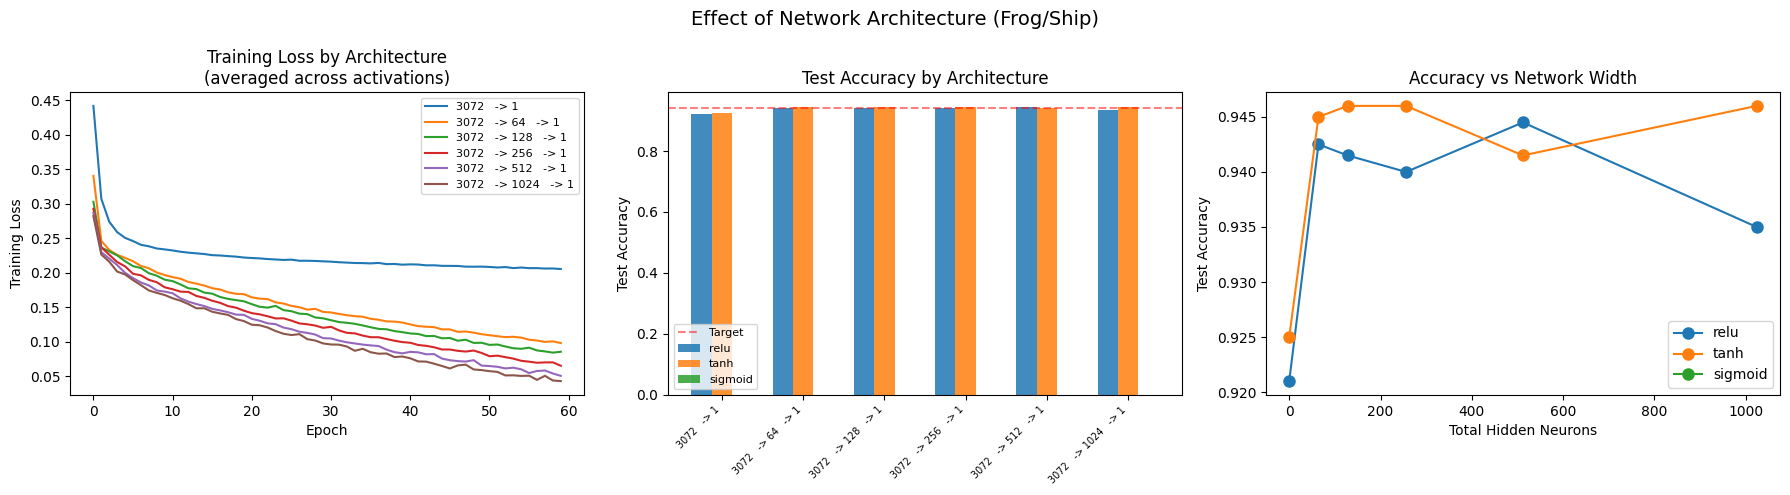

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))               
fig.suptitle('Effect of Network Architecture (Frog/Ship)',    
fontsize=14)                                              
            
# Extract helper columns                                           
results_df['activation'] = results_df['config'].apply(lambda c: c['activation'])                                                   
results_df['architecture'] = results_df['config'].apply(lambda c: '   -> '.join(map(str, c['layer_sizes'])))
results_df['num_hidden_layers'] = results_df['config'].apply(lambda c: len(c['layer_sizes']) - 2)
results_df['total_neurons'] = results_df['config'].apply(lambda c: sum(c['layer_sizes'][1:-1]))

# 1. Loss curves grouped by architecture (averaged across activations)
ax = axes[0]
for arch in results_df['architecture'].unique():
    subset = results_df[results_df['architecture'] == arch]
    # Average loss history across activations
    avg_history = np.mean(subset['loss_history'].tolist(), axis=0)
    ax.plot(avg_history, label=arch)
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.set_title('Training Loss by Architecture\n(averaged across activations)')
ax.legend(fontsize=8)

# 2. Test accuracy by architecture, grouped by activation          
ax = axes[1]                                                       
architectures = results_df['architecture'].unique()                
x = np.arange(len(architectures))              
width = 0.25                                   
for i, act in enumerate(['relu', 'tanh', 'sigmoid']):
    subset = results_df[results_df['activation'] == act]
    accuracies = []
    for a in architectures:
        match = subset[subset['architecture'] == a]
        accuracies.append(match['test_accuracy'].values[0] if
len(match) > 0 else 0)
    ax.bar(x + i * width, accuracies, width, label=act, alpha=0.85)
ax.set_xticks(x + width)
ax.set_xticklabels(architectures, fontsize=7, rotation=45,
ha='right')
ax.set_ylabel('Test Accuracy')
ax.set_title('Test Accuracy by Architecture')
ax.axhline(y=0.94, color='r', linestyle='--', alpha=0.5,
label='Target')
ax.legend(fontsize=8)

# 3. Total hidden neurons vs accuracy (each point is one run)
ax = axes[2]
for act in ['relu', 'tanh', 'sigmoid']:
    subset = results_df[results_df['activation'] == act]
    ax.plot(subset['total_neurons'], subset['test_accuracy'], 'o-',
label=act, markersize=8)
ax.set_xlabel('Total Hidden Neurons')
ax.set_ylabel('Test Accuracy')
ax.set_title('Accuracy vs Network Width')
ax.legend()

plt.tight_layout()
plt.show()

### Run tanh / relu / sigmoid for chosen model (3072-128-1, 1e-4, 100 epochs, 32 batch, adam opt)

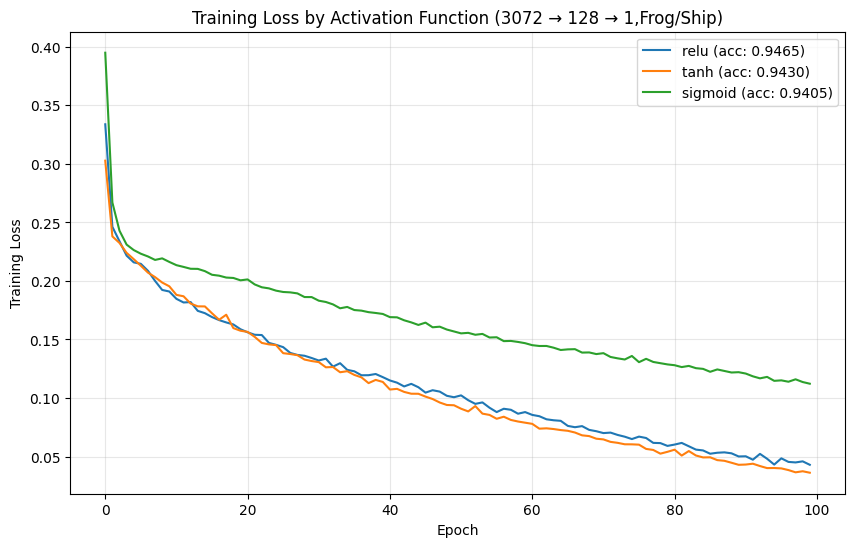

In [50]:
activation_comparison = []                                
                
for act in ['relu', 'tanh', 'sigmoid']:                            
    config = {                                                     
        'layer_sizes': [3072, 128, 1],                             
        'activation': act,                                         
        'lr': 1e-4,                            
        'epochs': 100,                         
        'batch_size': 32,                      
        'optimizer': 'adam',
    }
    result = pipeline(config, train_data_frog_ship, test_data_frog_ship)
    activation_comparison.append(result)

# Plot loss curves on same axes
plt.figure(figsize=(10, 6))
for res in activation_comparison:
    act = res['config']['activation']
    plt.plot(res['loss_history'], label=f"{act} (acc: {res['test_accuracy']:.4f})")

plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss by Activation Function (3072 → 128 → 1,Frog/Ship)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### Report on task 1.4 (see experiments above in this notebook)

As a starting point I tried to classify the frog / ship images with a logistic regression / one layer with one neuron network. This seemed to max out the accuracy at 93% with a learning rate of 1e-4. You can see the trajectories of the losses in the 4 chart panel below. In summary, 1e-2 looks too big and results in a volatile path that converges poorly, 1e-5 is smooth but very slow - could add more epochs and get better accuracy, but from a practical point of view I will use 1e-4 going forward when varying other parameters / using bigger networks. (in reality, it would be ideal to do a full sweep of all possible combinations of network width / depth, learning rates, batch sizes, optimizer types, epoch numbers etc but this is impractical here as would take too long!)

Also worth noting here is with a smaller learning rate, we probably need to run for more epochs since the convergence is obviously slower.

Next step was to try different sized models with 'relu' and 'tanh' activation between the layers (all using a lr=1e-4 from the previous step). Some notes on these experiments: The larger models achieve a lower train loss due to them having more parameters / being more flexible and fitting the training data better, but then they show larger test loss as they've gone too far and have overfitted the training set. So we can conclude that deeper models seem to overfit more (models to the left of the cluster on chart 4 below). What's interesting here is that the really wide model (3072-1024-512-1, with ~3.6M parameters) has a very large test loss ~ 0.55 relative to the other models which (i think) is an extreme case of overfitting. The lesson here is that a network with progressive narrowing is what we want, keeping the number of parameters under control and preventing overfitting - it seems that deeper and narrowing architectures learn increasingly compressed representations which generalise better. The second set of charts are the same but focus on shallower (3 layers) models with narrower (512 and lower) layers - this seems to be the 'sweet spot' for performance, but there's not much in it. All models were run with both RelU and tanh activation - I'm not entirely sure why ReLu underperforms Tanh in some cases and vice versa. It could be to do with the fact that tanh outputs +1/-1 wheras ReLu outputs 0 to infinity thereby losing signal for some of the neurons and causing them to 'die'. Tanh seems to do better for the bigger models. For this task though 3072-128-1 network seems to be the sweetspot and here both relu and tanh perform similarly.

   Architecture Activation Parameters Train Loss Test Loss Test Accuracy
 3072 → 512 → 1       relu  1,573,889     0.0463    0.1591        0.9475
3072 → 1024 → 1       tanh  3,147,777     0.0477    0.1639        0.9475
 3072 → 256 → 1       tanh    786,945     0.0655    0.1457        0.9470
 3072 → 128 → 1       relu    393,473     0.0816    0.1579        0.9455
3072 → 1024 → 1       relu  3,147,777     0.0362    0.1741        0.9450
  3072 → 64 → 1       relu    196,737     0.1059    0.1599        0.9435
 3072 → 128 → 1       tanh    393,473     0.0813    0.1539        0.9430
  3072 → 64 → 1       tanh    196,737     0.0992    0.1469        0.9425
 3072 → 256 → 1       relu    786,945     0.0682    0.1692        0.9390
 3072 → 512 → 1       tanh  1,573,889     0.0549    0.1683        0.9390
       3072 → 1       tanh      3,073     0.2067    0.2044        0.9240
       3072 → 1       relu      3,073     0.2063    0.2029        0.9225

Table shows the results for the smaller (3 layer) models. Losses are lower and accuracy higher than all of the larger / more complex models and I think for this kind of problem (i.e. very easy) having a more complex network doesn't really acheive anything and isn't necessary - will be interesting to see if the same applies to cat/dog and multiclass classification. Charts and more detailed results can be seen below NOTE cells must be run in order.

I think a model with [3072 → 128 → 1], relu, 393,473 parameters, train loss = 0.0816, test loss = 0.1579 and an accuracy of 0.9455 is a good place to finish this analysis. Given its size it performs well and I will now try it on the more difficult problem of cats and dogs.

Some other thoughts...

Input / output layers are not design choices - we are restricted to 3072 inputs by the image sizes and to 1 ouput neuron by the fact that we are performing binary classification.
Last layer needs a sigmoid activation function - we need to map the real number line to [0, 1]

The speed of convergence is slightly higher for tanh during comparitive training over 100 epochs. This might be the better option depending on what our specific circumstances are but there's not much in it on this problem.

A few observations:

Activation Function: ReLu is the winner here - but only just and on this problem, I would happily use relu or tanh. We obviously keep a sigmoid on the last layer for binary classification. Learning Rate: From simple experiments with the logistic network, 1e-4 seems to be stable and convergent. Probably needs 100+ epochs in order to reach its baseline.


### Task 1.5. Train the neural network to classify cat/dog images (9 points)


Now that you have optimized your network for frog/ship classification, try to solve cat/dog classification. This task is harder, because cats and dogs can have similar colors, shapes, and poses. Again, your neural network should achieve **>0.64 accuracy** on the test part.

First, try training the same network that you've optimized for the frog/ship task. Can it successfully solve cat/dog classification? If not, experiment with model architecture and hyperparameters again.

In this task you might also need to use BatchNorm and Dropout layers. Here's documentations:
- BatchNorm: https://docs.pytorch.org/docs/stable/generated/torch.nn.BatchNorm1d.html
- Dropout: https://docs.pytorch.org/docs/stable/generated/torch.nn.Dropout.html

**Note:** Both BatchNorm and Dropout layers behave differently on training and inference. Don't forget to set `model.train()` and `model.eval()` before training/evaluation phases.

Below there's also theory block on BatchNorm.

After you've done experimenting, describe your findings. Again, try to answer the following questions:
- How large should the neural network be to solve the task successfully? Is that different from what you had on the frog/ship task?
- How does the behaviour of the model change when you change different hyperparameters?
- What interesting behaviour have you observed? What was beneficial and what did not influence the model?
- How does the number of epochs needed to achieve the same loss value change when you change the activation function? Fix the network architecture and all training hyperparameters and train the neural network with three different activation functions in hidden layers (Sigmoid, Tanh, ReLU). Plot how training loss evolves during training in these three cases.

Here is also an example of visual appearance of these classes — you may want to inspect several training images manually to understand why the task is difficult.


In [51]:
# first define new dataloaders for train/test on train_data_cat_dog/test_data_cat_dog
train_dataset = BinaryClassificationDataset(train_data_cat_dog)
test_dataset = BinaryClassificationDataset(test_data_cat_dog)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True) # define a train loader
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False) # Define a test loader


In [52]:
# Define NN structure $ forward function

class CatDogNet(nn.Module):                                        
      def __init__(self):                                       
          super(CatDogNet, self).__init__()                 
                                                                     
          self.linear1 = nn.Linear(3072, 1024)
          self.bn1 = nn.BatchNorm1d(1024)                            
          self.linear2 = nn.Linear(1024, 512)                        
          self.bn2 = nn.BatchNorm1d(512)                             
          self.linear3 = nn.Linear(512, 128)
          self.bn3 = nn.BatchNorm1d(128)         
          self.linear4 = nn.Linear(128, 1)

          self.relu = nn.ReLU()
          self.dropout = nn.Dropout(0.3)
          self.sigmoid = nn.Sigmoid()

      def forward(self, x):
          x = self.relu(self.bn1(self.linear1(x)))
          x = self.dropout(x)
          x = self.relu(self.bn2(self.linear2(x)))
          x = self.dropout(x)
          x = self.relu(self.bn3(self.linear3(x)))
          x = self.dropout(x)
          x = self.sigmoid(self.linear4(x))
          return x

#Create instance of model
cat_dog_net = CatDogNet()

# loss function
criterion = nn.BCELoss() # define a loss function (binary cross-entropy)
# optimizer
optimizer = torch.optim.Adam(cat_dog_net.parameters(), lr=1e-4) # define an optimizer and pass params of neural network to it


# run training
cat_dog_net, loss_history_cat_dog = train(cat_dog_net, train_loader, criterion, optimizer, 100)


# 6. Evaluate accuracy
mean_loss, accuracy = evaluate(cat_dog_net, test_loader, criterion)
print(f"Test Loss: {mean_loss:.4f}, Test Accuracy: {accuracy:.4f}")

# Network summary                                     
print(f"\nNetwork Architecture: {cat_dog_net}")                 
print(f"\nTotal parameters: {sum(p.numel() for p in cat_dog_net.parameters()):,}")                                  
print(f"Trainable parameters: {sum(p.numel() for p in cat_dog_net.parameters() if p.requires_grad):,}")               
                
# Per-layer breakdown                          
print("\nLayer details:")
for name, param in cat_dog_net.named_parameters():
    print(f"  {name}: {list(param.shape)} ({param.numel():,} params)")

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [04:51<00:00,  2.91s/it]

Test Loss: 1.3389, Test Accuracy: 0.6430

Network Architecture: CatDogNet(
  (linear1): Linear(in_features=3072, out_features=1024, bias=True)
  (bn1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (linear2): Linear(in_features=1024, out_features=512, bias=True)
  (bn2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (linear3): Linear(in_features=512, out_features=128, bias=True)
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (linear4): Linear(in_features=128, out_features=1, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (sigmoid): Sigmoid()
)

Total parameters: 3,740,673
Trainable parameters: 3,740,673

Layer details:
  linear1.weight: [1024, 3072] (3,145,728 params)
  linear1.bias: [1024] (1,024 params)
  bn1.weight: [1024] (1,024 params)
  bn1.bias: [1024] (1,024 params)
  linear2.weight: [512, 1024] (524,288 params)
  linear2.bias: [512] 

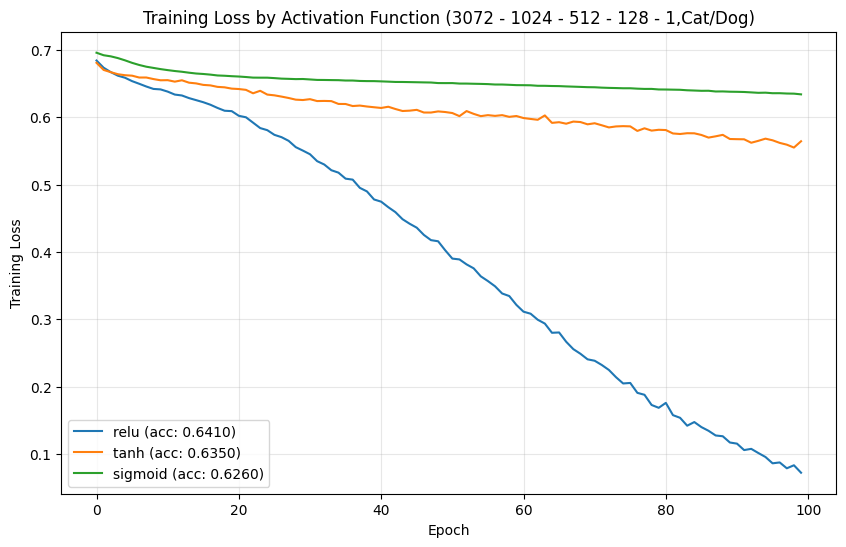

In [ ]:
# Compare the training loss for relu, simoid and tanh - note pipeline function
# doesn't use batch norm / dropout so the results here aren't as good - I didn't 
# have time to rewrite so absolute performance isn't as good as CatDogNet above

activation_comparison = []                                
                
for act in ['relu', 'tanh', 'sigmoid']:                            
    config = {                                                     
        'layer_sizes': [3072, 1024, 512, 128, 1],                             
        'activation': act,                                         
        'lr': 1e-5,                            
        'epochs': 100,                         
        'batch_size': 32,                      
        'optimizer': 'adam',
    }
    result = pipeline(config, train_data_cat_dog, test_data_cat_dog) 
    activation_comparison.append(result)

# Plot loss curves on same axes
plt.figure(figsize=(10, 6))
for res in activation_comparison:
    act = res['config']['activation']
    plt.plot(res['loss_history'], label=f"{act} (acc: {res['test_accuracy']:.4f})")

plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss by Activation Function (3072 - 1024 - 512 - 128 - 1,Cat/Dog)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### Report on task 1.5

In order to get the network to achieve greater than 0.64 accuracy, I first added layers then widened those layers. Neither worked so I added batch norm and dropout which gave the desired accuracy (0.6495 on 100 epochs). Tried tanh activation but only got to 0.61 under the same circumstances. Dropout p value was set at 0.3 and this seemed to work fine - recommendation was 0.2-0.5 from the literature / web so i went for something in the middle.

So the loss charts for this more complex model appear less stable than with the simpler model from the frog/ship example when using 1e-4 as a learning rate. Having experimented with lr = 1e-5 I think that this might be a better choice for this model. Like before the loss is still falling after 100 epochs and so we should probably train for longer. Unlike in the first case, 'relu' is the clear winner here - it achieves a smaller loss and falls more quickly than with tanh. Sigmoid is a poor third place.

Great! Now that we've tried to solve binary classification on CIFAR-10 data, we'll switch to the task of **multi-class classification**. But before that, let's talk about the `Dataset` class in PyTorch.


#### BatchNorm

Now let us talk about a new type of network layer: batch normalization. This is a layer that helps make training more stable and faster. In addition, a neural network with batch normalization layers can often learn a task better than the same network without batch normalization.

Let us consider a neural network with several layers. Notice that layers 2–3 of this network can be viewed as a separate, smaller neural network. The input data for this smaller network are the outputs of the first layer.

We already know that, for better neural network training, the input data should be normalized. Therefore, normalizing the outputs of each intermediate layer also helps the network train better. BatchNorm is exactly the layer that performs this kind of normalization.

There is also a second reason to normalize the outputs of intermediate layers. This is the internal covariate shift effect in neural networks. Originally, BatchNorm was introduced as a way to eliminate this effect.

network.svg

What is internal covariate shift? Consider a neural network with several layers. During training, all layers are trained jointly. Each layer of the network must adapt to the values produced by the previous layer. However, during training, the distribution of values produced by each layer changes. As a result, at every iteration of the algorithm, each hidden layer has to adapt to a new distribution of outputs from the previous layer. This makes the network train more slowly. Moreover, the weights can change quite significantly at each training iteration, which may provoke other problems, such as exploding gradients.

Normalizing the outputs of the network layers would help solve this problem.

So, how can we implement normalization of layer outputs? The simplest idea is to strictly normalize the output of each layer before passing it further through the network, just as we normalize the input data. For example, we could force the mean of all layer outputs to be 0 and the variance to be 1.

But why not give the neural network more freedom and allow it to determine for itself how exactly it is best to normalize the outputs of each layer?

That is precisely the idea behind BatchNorm. BatchNorm is a trainable layer that normalizes network outputs using trainable parameters.


**A BatchNorm layer is applied after a network layer and works as follows:**

1. Compute the mean $\mu_B$ and variance $\sigma_B$ of the layer outputs over the batch. That is, suppose we have b outputs of the layer $\{x_i\}_{i=1}^b$, where $b$ is the batch size. Then:
    
$$\mu_B = \frac{\sum_{i=1}^b x_i}{b}$$

$$\sigma_B^2 = \frac{\sum_{i=1}^b (x_i - \mu_B)^2}{b}$$

2.	Normalize the layer outputs:

$$\widehat{x_i} = \frac{x_i - \mu_B}{\sigma_B}$$

3.	Compute the updated layer outputs as

$$y_i = \gamma \widehat{x_i} + \beta$$

where $\gamma$ and $\beta$ are trainable parameters.

Basically, BatchNorm shifts mean of each neuron's output in the current batch to $\beta$, and variance to $\gamma$.

However, in this setup we will have a problem on inference, when we should be able to compute network's predictions on a single element. If we have only one element in a batch, we can't reliably estimate mean and variance to apply BatchNorm. The idea of a fix here is the following: during inference, we will use statistics for $\mu_B$ and $\sigma^2_B$ that we have computed during training.

For this reason, BatchNorm behaves differently during training and during inference. **During training, BatchNorm will do the following:**

Initialize running mean $\mu_r$ and $\sigma_B$ as zero. Set *momentum* hyperparameter to some constant between 0 and 1.

1. Compute the mean $\mu_B$ and variance $\sigma_B$ of the layer outputs over the batch. That is, suppose we have b outputs of the layer $\{x_i\}_{i=1}^b$, where $b$ is the batch size. Then:
    
$$\mu_B = \frac{\sum_{i=1}^b x_i}{b}$$

$$\sigma_B^2 = \frac{\sum_{i=1}^b (x_i - \mu_B)^2}{b}$$

Update the running mean and running variance:

$$\mu_r = (1-momentum)*\mu_r + momentum*\mu_B$$
$$\sigma_r = (1-momentum)*\sigma_r + momentum*\sigma_B$$

2.	Normalize the layer outputs:

$$\widehat{x_i} = \frac{x_i - \mu_B}{\sigma_B}$$

3.	Compute the updated layer outputs as

$$y_i = \gamma \widehat{x_i} + \beta$$

where $\gamma$ and $\beta$ are trainable parameters.

Then we use $\mu_r$ and $\sigma_r$ during inference instead of batch-based statistics. So, **during inference BatchNorm does the following:**

1. Normalize the layer outputs:

$$\widehat{x_i} = \frac{x_i - \mu_r}{\sigma_r}$$

3.	Compute the updated layer outputs using trained $\gamma$ and $\beta$ as

$$y_i = \gamma \widehat{x_i} + \beta$$



## Task 2. Dataset class


In the task above we worked with CIFAR-10 data that we loaded into NumPy/Pandas structures and then passed directly to dataloaders. In PyTorch there is a class called `Dataset` which allows us to work with data in a more flexible way. It lets us define custom transformations of the data before passing it into the model.

In this task you will need to define a `Dataset` class based on our CIFAR-10 data. We will then use it for training a neural network for multi-class classification of the whole CIFAR-10 dataset.


In [54]:
import torch
from torch.utils.data import Dataset, DataLoader

### Task 2.1 Implement `CIFAR10Dataset` class. (9 points)


Your task is to fill in the blanks in the cell below. Please note the following:
- The `__init__` method usually stores the input data in class variables. In our case the data comes into `__init__` as a pandas DataFrame. To access elements by index faster in the `__getitem__` method, convert the data to `np.array` format inside `__init__`.
- If you want to apply transformations to the data before feeding it to the neural network (normalization, reshaping, etc.), this is usually done in the `__getitem__` method. We would like to normalize our images, i.e. bring all pixel values to the interval `[0, 1]`. To do this, divide all pixel values by `255.`. Note that normalization should be done in the `__getitem__` method, **not** in `__init__`. This is checked by asserts later and by the testing system when the task is submitted.
- Below you will train a neural network to classify CIFAR images into 10 classes using this Dataset class. You might experiment with other transformations to help your network fit better. For example, you might want to resize images before feeding them into the model or convert images into grayscale — this would lower number of image pixels by 3! Pillow library (https://pypi.org/project/pillow/) can help you with that. You will need first to reshape your image vector into 32x32x3, convert to Pilow Image format, resize/do other transformations, concert back to Numpy and flatten the image back into the vector. You can think of other transformations that might help.


**Note**: here we start to use all labels in CIFAR dataset, as below we will build a neural network for multi-class classification (all 10 CIFAR classes). So you don't need to select data elements with certain labels anymore.

In [55]:
class CIFAR10Dataset(Dataset):
    def __init__(self, data):
        '''
        params:
            data (pd.DataFrame) — dataframe with flattened CIFAR-10 images and column `label`
        '''

        # load the data and
        # split it into features and target variable
        # and convert both to np.array
        # please do not change names of variables self.X and self.y,
        # it is important for the checks below to work correctly
        
        # features
        self.X = data.drop(columns=['label']).values.astype(float)
        # target variable
        self.y = data['label'].values.astype(int)

    def __len__(self):
        '''
        method that returns the number of objects in a dataset.
        This method is used by dataloader to generate batches of data
        '''
        return len(self.X)

    def __getitem__(self, idx):
        '''
        method that, given an index idx, returns the dataset object
        corresponding to the index.
        This method is used by dataloader to form batches of data
        params:
            idx: index of an element of the data
        '''

        # - get an object of data by index idx;
        # - normalize features (divide each pixel by 255.);
        # - convert features and target to tensor
        features = torch.tensor(self.X[idx]/255, dtype = torch.float32)
        labels = torch.tensor(self.y[idx], dtype = torch.long)
        return features, labels

Now we can define training and testing datasets. We'll do this for multi-class classification using the whole CIFAR-10 dataframe.


In [56]:
cifar_train_dataset = CIFAR10Dataset(train_data)
cifar_test_dataset = CIFAR10Dataset(test_data)


The cell below checks that your Dataset class is implemented correctly


In [57]:
# check that types of self.X and self.y are np.array
assert type(cifar_train_dataset.X) == np.ndarray, "type of self.X in cifar_train_dataset is not np.array"
assert type(cifar_train_dataset.y) == np.ndarray, "type of self.y in cifar_train_dataset is not np.array"

# check that data is not normalized in __init__ method
assert max(cifar_train_dataset.X[0]) == 255, "data should not be normalized in __init__ method"

# check that data is normalized correctly in __getitem__ method
assert float(torch.max(cifar_train_dataset[0][0])) <= 1.0, "data is not normalized in __getitem__ method or it is normalized incorrectly"
assert float(torch.min(cifar_train_dataset[0][0])) >= 0.0, "data is not normalized in __getitem__ method or it is normalized incorrectly"

# check that __getitem__ returns tensors
assert type(cifar_train_dataset[0][0]) == torch.Tensor, '__getitem__ returns other data type than tensor'
assert type(cifar_train_dataset[0][1]) == torch.Tensor, '__getitem__ returns other data type than tensor'


Great! After this we're ready to use our datasets. Now we can use `cifar_train_dataset` and `cifar_test_dataset` in `DataLoader`:


In [58]:
train_loader = torch.utils.data.DataLoader(cifar_train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(cifar_test_dataset, batch_size=64, shuffle=False)


Now we will train and test our network for multi-class classification using these new dataloaders.


## Task 3. Multi-class classification with NNs


### Neural network for multi-class classification


We already know how to build a neural network for the tasks of binary classification and regression. Let's learn what to do if we have a task of multi-class classification.



Consider a dataset for classification of crocodiles into 3 types:


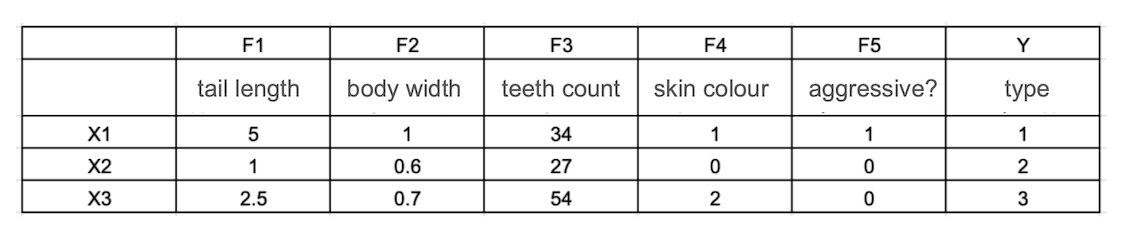


The simplest idea of neural network architecture for this task would be having one output neuron, which would output the class number of input object.


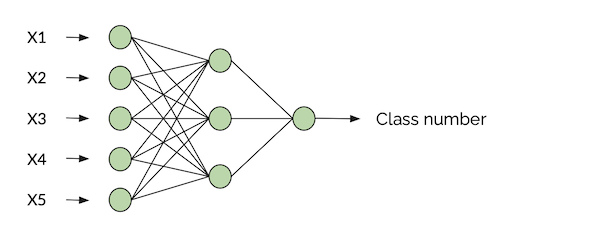


But there's a problem: how do we interpret outputs of such network? Let's say for some object our network outputs the value of 2.12. Does it mean that most likely our object belongs to the class 2? Or does the network think that the object is somewhere in between classes 1 and 3?


Okay, this was not the greatest idea. Let's now note, that a task of milti-class classification to $n$ classes can be wieved as $n$ binary classification tasks:
- does element belong to class 1?
- does element belong to class 2?
- ...
- does element belong to class n?

We can then make our neural network have n output neurons with Sigmoid activation function, and each output neuron will solve a corresponding binary classification tasks. So in our case with crocodile data it will look like that:


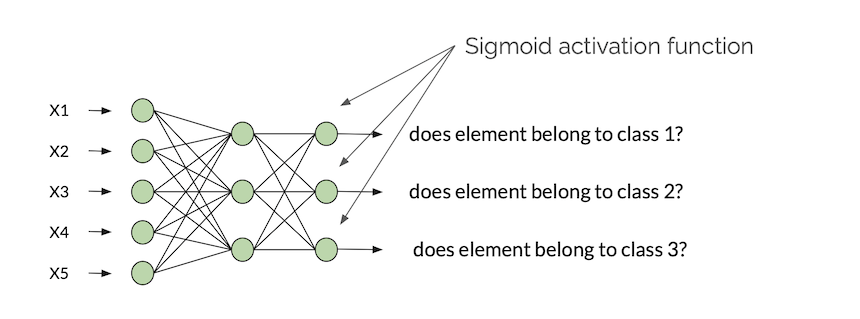


Such a network structure is suitable for the task of multi-label classification, where each input object can belong to arbitrary number of classes, i.e. where events "input object X belongs to class i" are independent. In the case of multi-class classification, these events are not independent, as each object can only belong to one class. So we would like decisions of neuron of the last layer to be agreed in some way.


The idea that comes to mind is the following: we would like neurons of the last layer to output a probability distribution over the classes. This means that the output of $i^{th}$ neuron will represent a probability that the input object belongs to the class $i$.

We also know the true distribution for each object, which is represented as one-hot vector. So as a loss function we could use some similarity measure between the true and predicted distributions.


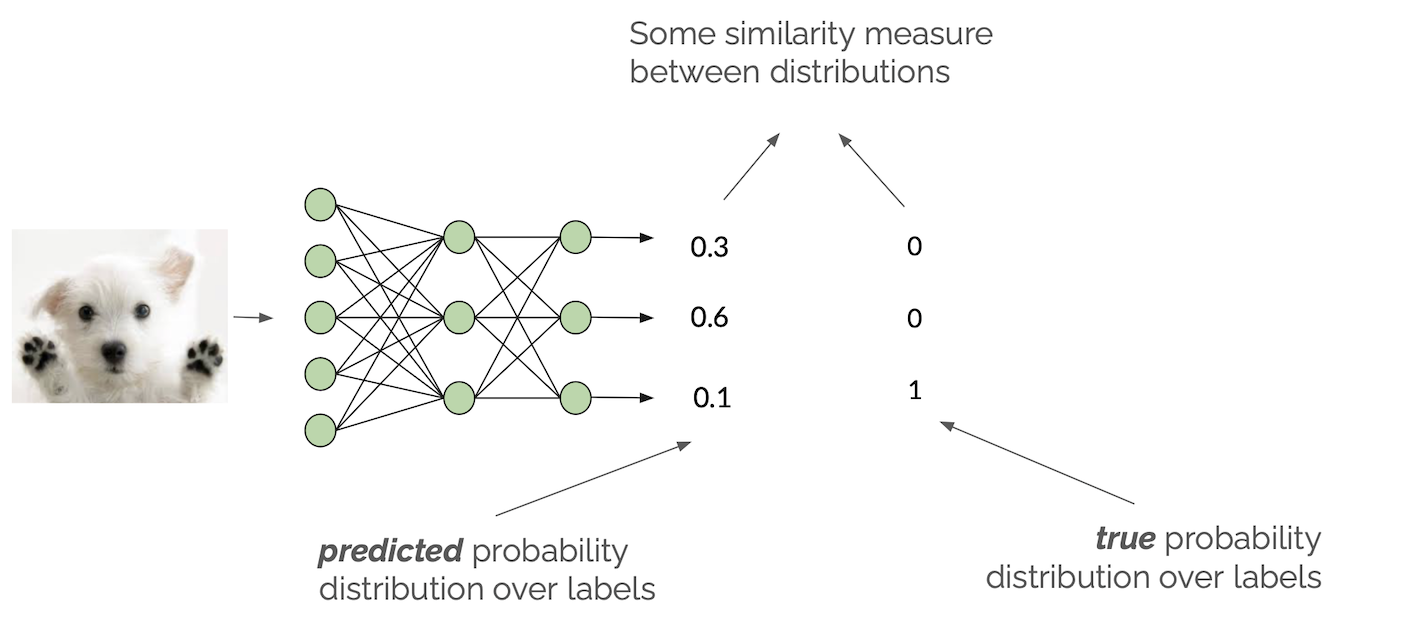


So we need to somehow convert the logits (outputs of the last linear layer) into the probability distribution. Let's do it using SoftMax activation function:

$$(p_1, p_2, p_3) = SoftMax(\widehat{p_1}, \widehat{p_2}, \widehat{p_3}) = \left( \frac{e^{\widehat{p_1}}}{\sum e^{\widehat{p_i}}}, \frac{e^{\widehat{p_2}}}{\sum e^{\widehat{p_i}}}, \frac{e^{\widehat{p_3}}}{\sum e^{\widehat{p_i}}} \right)$$

We can see that SoftMax does indeed convert logits into probability distribution, as the sum of all elements becomes 1, and value of each element is in $[0, 1]$.

And as a similarity measure between the output distribution and true distribution we will use [cross-entropy](https://en.wikipedia.org/wiki/Cross-entropy), which is a measure of similarity of two probability distrubutions from information theory.

$$CE(y, p) = - \sum y_i log(p_i)$$

LogLoss is a binary version of cross-entropy.





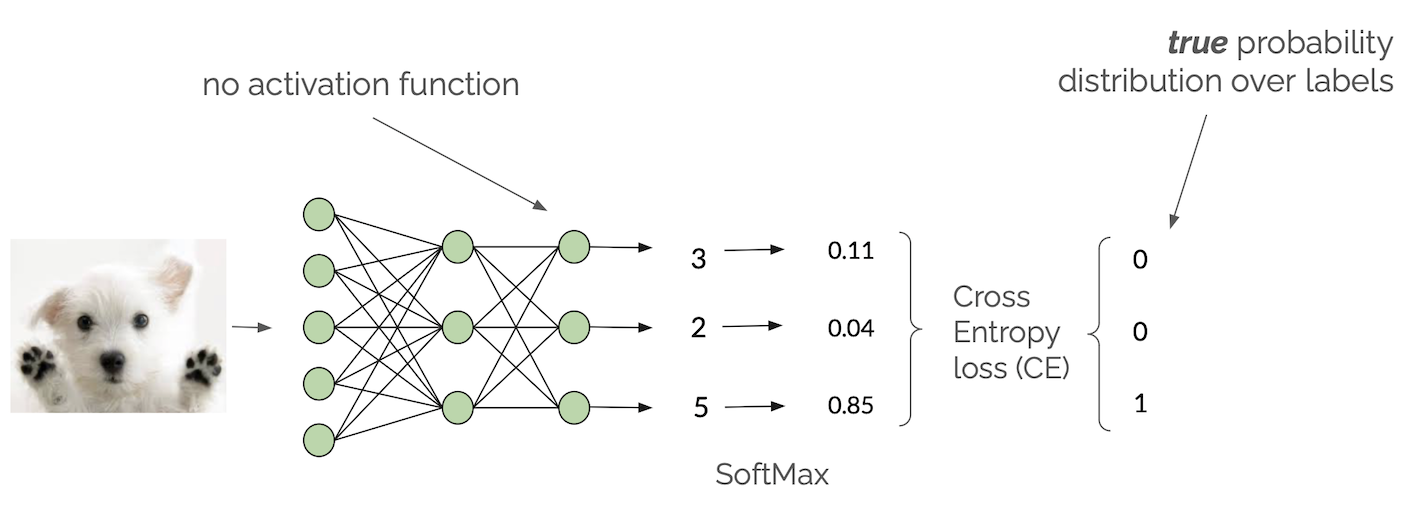


Let's also say a couple of words about why using SoftMax, as there are many ways to convert logits into probability distribution.

First, here's log function inside the formula of cross-entropy. If we pass logits $\widehat{p_i}$ through exponential function before feeding them into cross-entropy, we will end up $log(p_i)$ having the same magnitude as $\widehat{p_i}$. So this will encourage a neural network to output logits which have the same magnitude as $y_i$.

Second, SoftMax is a short for "Soft Maximum", and it has this name because it rebalances the values so that the maximum value becomes more pronounced, close to 1, while all other values get closer to zero.

Here's an example of how SoftMax changes logits:


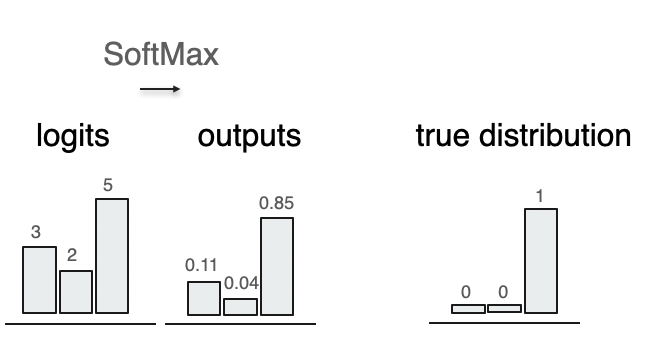


So it is called "Soft Maximum", as it acts almost like argmaximum function, but softer, not putting all the probability weight into one place.


To sum up, if you are building neural network for $n$-class classification task with $n>2$, then:
- last layer of the network should have $n$ neurons
- activation of the last layer of the network should be SoftMax (https://pytorch.org/docs/stable/generated/torch.nn.Softmax.html)
- loss function is cross-entropy (https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)

Note, however, that PyTorch implementation of CE (torch.nn.CrossEntropyLoss) expects to have logits as input, not probabilities after SoftMax. It applies SoftMax inside loss function. This is done due to efficiency of computing gradients. So if you use torch.nn.CrossEntropyLoss as loss function, there should be no activation function in the last layer of the network.


### Task 3.1 Write a neural network for multi-class classification (4 points)


Define a neural network that should solve a multi-class classification task with 10 classes on CIFAR-10. Think about the following:
- How many input and output neurons should your network have?
- What activation function should the last layer have?


In [59]:
import torch.nn as nn

class MultiClassNet(nn.Module):
    def __init__(self):                                            
        super(MultiClassNet, self).__init__()
                
        self.linear1 = nn.Linear(3072, 512)    
        self.bn1 = nn.BatchNorm1d(512)
        self.linear2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)
        self.linear3 = nn.Linear(256, 10)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.relu(self.bn1(self.linear1(x)))
        x = self.dropout(x)
        x = self.relu(self.bn2(self.linear2(x)))
        x = self.dropout(x)
        x = self.linear3(x)
        return x



And create a network:


In [60]:
NN = MultiClassNet()


### Task 3.2 Define a train function (4 points)


You can copy it from the task above. Does the train function need any modification given that now we're solving a multi-class classification task?


In [61]:
import tqdm
from tqdm.auto import tqdm

# define a function
# you can change arguments of this function if you want
def train(model, dataloader, criterion, optimizer, num_epoch):
    model.train()
    
    loss_history = []
    
    for epoch in tqdm(range(num_epoch)):
        epoch_loss = 0.0
        for x, y in dataloader:
            optimizer.zero_grad()
            y_pred = model(x)
            loss = criterion(y_pred, y)
            
            epoch_loss += loss.item()
            loss.backward()
            optimizer.step()
            
        loss_history.append(epoch_loss / len(dataloader))
        
    return model, loss_history  


And let's define loss function, optimizer, dataloader and train our network. Use the full `cifar_train_dataset` here.


In [62]:
# loss function
criterion = nn.CrossEntropyLoss() 
# optimizer
optimizer = torch.optim.Adam(NN.parameters(), lr=1e-3)
# dataloader
train_loader = torch.utils.data.DataLoader(cifar_train_dataset, batch_size=64, shuffle=True)

# run training
NN, loss_history = train(NN, train_loader, criterion, optimizer, 200)


100%|██████████| 200/200 [1:38:08<00:00, 29.44s/it]   


### Task 3.3. Write a code for model evaluation (4 points)


Again, you can borrow the code from the task above. Does the train function need any modification given that now we're solving a multi-class classification task?


In [63]:
def evaluate(model, loader, criterion):
    '''
    args:
        model - our neural network model
        loader — structure which yields batches of test data
        criterion - loss function from `torch.nn` module
    '''

    # arrays for storing loss values, network predictions and true values
    model.eval()
    losses = []
    y_pred_list = []
    y_true_list = []

    for X_batch, y_batch in loader:

        # this disables gradient computations to save time and memory
        # we don't need gradients on test data
        with torch.no_grad():
            # getting our model's predictions on current batch
            y_pred = model(X_batch)

            # calculate loss function
            loss = criterion(y_pred, y_batch)
            losses.append(loss.item())


        # convert outputs of your network into class number
        y_pred_class = torch.argmax(y_pred, dim=1)
        y_pred_list.extend(y_pred_class.cpu().numpy())
        y_true_list.extend(y_batch.cpu().numpy())

        

    # calculate accuracy score based on y_pred_list and y_true_list
    accuracy = accuracy_score(y_true_list, y_pred_list)
    

    return np.mean(losses), accuracy


### Task 3.4 Train the neural network. (9 points)


Here, again, your task is to improve the network so that it can achieve higher accuracy. Try to achieve **>0.53 accuracy** on the CIFAR-10 test part, but in general your goal is to improve as much as possible.

You are free to build any neural network architecture you want and use any hyperparameters for training. Here are some tips:
- Start with 1-3 hidden layers having, for example, 128-512 neurons each
- Think about how many neurons your input and output layers should have
- What activation function do you need to use in the last layer? **Be careful here:** check the documentation of the loss function that use are using: does it require logits or probabilities?
- Play with number of layers, numbers of neurons, and different activation functions
- Try different training hyperparameters: learning rate, number of epochs, optimizer type, batch size
- As we've discussed above, play with data preprocessing in the Dataset class.

While you're doing experimenting, describe your findings. Try to answer the following questions:
- How large should the neural network be to solve the task successfully? There are two dimensions to neural network size: **depth** and **width**.
- How does the behaviour of the model change when you change different hyperparameters?
- What interesting behaviour have you observed? What was beneficial and what did not influence the model?
- How does the number of epochs needed to achieve the same value of loss function change when you change the activation function? Fix the network architecture and all training hyperparameters and train the neural network with three different activation functions in hidden layers (Sigmoid, Tanh, ReLU). Plot how training loss evolves during training in these three cases.


In [65]:
test_loader = torch.utils.data.DataLoader(cifar_test_dataset, batch_size=64, shuffle=False)

evaluate(NN, test_loader, criterion)

(np.float64(1.8064964721157293), 0.5684)

OK so this meets the criterion - let's try a bigger / wider network with dropout and batch norm and 200 epochs to see if we can get even better accuracy.

In [66]:
class MultiClassNet2(nn.Module):
    def __init__(self):                                            
        super(MultiClassNet2, self).__init__()
                
        self.linear1 = nn.Linear(3072, 1024)    
        self.bn1 = nn.BatchNorm1d(1024)
        self.linear2 = nn.Linear(1024, 512)
        self.bn2 = nn.BatchNorm1d(512)
        self.linear3 = nn.Linear(512, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.linear4 = nn.Linear(128, 10)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.relu(self.bn1(self.linear1(x)))
        x = self.dropout(x)
        x = self.relu(self.bn2(self.linear2(x)))
        x = self.dropout(x)
        x = self.relu(self.bn3(self.linear3(x)))
        x = self.dropout(x)
        x = self.linear4(x)
        return x

WideNN = MultiClassNet2()

optimizer = torch.optim.Adam(WideNN.parameters(), lr=1e-3)         

WideNN, loss_history = train(WideNN, train_loader, criterion, optimizer, 200)

evaluate(WideNN, test_loader, criterion)


100%|██████████| 200/200 [29:55<00:00,  8.98s/it]


(np.float64(1.9347774306679988), 0.5885)

Better! Accuracy of 0.5885! Could probably improve further by adding epochs (loss curves are still falling), using a more complex network (wider layers seem to give the net the ability to process a more refined representation of the images and better distinguish the subtleties) etc. but time constraints mean i have to move on! (I actually think that this is an interesting point - when is the model 'good enough'? At some point the practical considerations of marginal improvement probably give way to the fact that the model is doing what was asked of it - possibly due to the bias / variance tradeoff.)


  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [14:40<00:00,  8.80s/it]


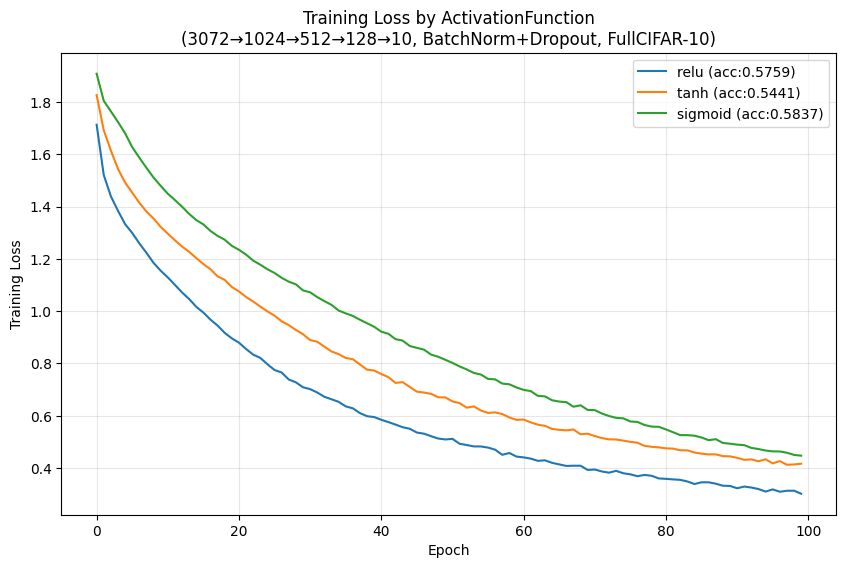

In [67]:
# Compare the training loss for relu, simoid and tanh (have used 100 epochs due to time constraints)
activation_comparison_mc = []                                 
                                                            
for act_name in ['relu', 'tanh', 'sigmoid']:
    act_map = {'relu': nn.ReLU(), 'tanh': nn.Tanh(), 'sigmoid': nn.Sigmoid()}                                                      
    activation_fn = act_map[act_name]                              
                                                                    
    # Build model dynamically                  
    model = nn.Sequential(                     
        nn.Linear(3072, 1024),                 
        nn.BatchNorm1d(1024),
        activation_fn,
        nn.Dropout(0.3),
        nn.Linear(1024, 512),
        nn.BatchNorm1d(512),
        activation_fn,
        nn.Dropout(0.3),
        nn.Linear(512, 128),
        nn.BatchNorm1d(128),
        activation_fn,
        nn.Dropout(0.3),
        nn.Linear(128, 10),
    )

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    train_loader = DataLoader(cifar_train_dataset, batch_size=64,shuffle=True)
    test_loader = DataLoader(cifar_test_dataset, batch_size=64,shuffle=False)

    # Train
    model, loss_history = train(model, train_loader, criterion, optimizer, 100)

    # Evaluate
    test_loss, test_accuracy = evaluate(model, test_loader, criterion)

    activation_comparison_mc.append({
        'activation': act_name,
        'loss_history': loss_history,
        'test_loss': test_loss,
        'test_accuracy': test_accuracy,
    })

# Plot
plt.figure(figsize=(10, 6))
for res in activation_comparison_mc:
    plt.plot(res['loss_history'], label=f"{res['activation']} (acc:{res['test_accuracy']:.4f})")

plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss by ActivationFunction\n(3072→1024→512→128→10, BatchNorm+Dropout, FullCIFAR-10)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### Report on task 3.4

- What activation function do you need to use in the last layer? **Be careful here:** check the documentation of the loss function that use are using: does it require logits or probabilities?

*We don't need an activation function here - just use the logits from the network and pass them to the nn.CrossEntropyLoss() function which includes a softmax activation followed by a cross entropy loss calculation.*

- Play with number of layers, numbers of neurons, and different activation functions

*As can be seen from the above runs, number of layers needed to be increased as did the depth of the network (from the simple net we used in the earlier question) in order to get meaningful results here. So more neurons overall. Relu was the best activation function again. This can be seen in the below chart where the gradient of the loss curve and the final loss reached (100 epochs) are steeper / lower than with tanh. Sigmoid comes last again.*

- Try different training hyperparameters: learning rate, number of epochs, optimizer type, batch size

*As the runs were starting to get very slow I reverted to using a 1e-3 learning rate but this does show some increased instability relative to the 1e-4 used in the previous section. In reality as always this is a bit of a compromise given the circumstances - would probably opt for >100 epochs with a lr=1e-4 in 'production'.*

- How large should the neural network be to solve the task successfully? There are two dimensions to neural network size: **depth** and **width**.
- How does the behaviour of the model change when you change different hyperparameters?
- What interesting behaviour have you observed? What was beneficial and what did not influence the model?

*Deeper / wider network with more neurons and dropout plus batchnorm was necessary here. I experimented initially with the model that we used for cat / dog classification but it was clear that this wasn't sophisicated enough and it was only by increasing the number of neurons sufficiently that I got the desired result. Clearly this slowed the training process down but by using lr=1e-3 and training for 100 epochs we could reach the target. Better performance can surely be achieved with more epochs and slower convergence but there wasn't time / need to do that here.*

- How does the number of epochs needed to achieve the same value of loss function change when you change the activation function? Fix the network architecture and all training hyperparameters and train the neural network with three different activation functions in hidden layers (Sigmoid, Tanh, ReLU). Plot how training loss evolves during training in these three cases.

*It can be seen below that for the same value of loss the training time required by tanh and sigmoid is much greater than that for relu (sigmoid > tanh > relu)*

*One other note here - I used Adam optimisation throughout as it adapts learning rates for each parameter, making it more forgiving than SGD which requires careful tuning of learning rate and momentum. In my experience it works better so I just went with it.

That's it for the tasks in this notebook!
